In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import PchipInterpolator

se_to_sd = lambda x: x * np.sqrt(100_000)*0

_TRUE_COEF = 2.0
_LAMBDA_VALUES = [0, 0.01, 0.025, 0.05, 0.1, 0.25]

_UNKNOWN_COEFS_RAW = [1.977021, 1.953432, 1.923165, 1.874825, 1.785176, 1.561425]
_UNKNOWN_COEFS_RAW_SD = list(map(se_to_sd, [0.001572, 0.001596, 0.001625, 0.001670, 0.001747, 0.001919]))
_UNKNOWN_COEFS_ORTH = [1.900105, 1.804291, 1.704541, 1.594019, 1.464834, 1.284655]
_UNKNOWN_COEFS_ORTH_SD = list(map(se_to_sd, [0.003728, 0.003506, 0.003254, 0.002982, 0.002690, 0.002410]))

_KNOWN_COEFS_RAW = [1.977021, 1.918703, 1.880067, 1.850144, 1.826842, 1.866534]
_KNOWN_COEFS_RAW_SD = list(map(se_to_sd, [0.001572, 0.001574, 0.001592, 0.001639, 0.001753, 0.001170]))
_KNOWN_COEFS_ORTH = [1.900105, 1.855786, 1.808940, 1.775253, 1.754497, 1.761303]
_KNOWN_COEFS_ORTH_SD = list(map(se_to_sd, [0.003728, 0.003217, 0.002875, 0.002692, 0.002663, 0.002106]))

_UNKNOWN_P_COEFS_RAW = [-6.222743, -6.128556, -5.986766, -5.760226, -5.340236, -4.293659]
_UNKNOWN_P_COEFS_RAW_SD = list(map(se_to_sd, [0.001069, 0.001101, 0.001144, 0.001209, 0.001323, 0.001570]))
_UNKNOWN_P_COEFS_ORTH = [-5.927320, -4.875475, -3.798249, -2.690120, -1.544799, -0.0370340]
_UNKNOWN_P_COEFS_ORTH_SD = list(map(se_to_sd, [0.002552, 0.002625, 0.002609, 0.002456, 0.002119, 0.001571]))

_KNOWN_P_COEFS_RAW = [-6.222743, -4.972770, -4.038061, -3.232550, -2.453473, -1.584590]
_KNOWN_P_COEFS_RAW_SD = list(map(se_to_sd, [0.001069, 0.000907, 0.000883, 0.000920, 0.001002, 0.001170]))
_KNOWN_P_COEFS_ORTH = [-5.927320, -4.089466, -2.847046, -2.010909, -1.388702, -0.779137]
_KNOWN_P_COEFS_ORTH_SD = list(map(se_to_sd, [0.002552, 0.002355, 0.002259, 0.002692, 0.002075, 0.002106]))

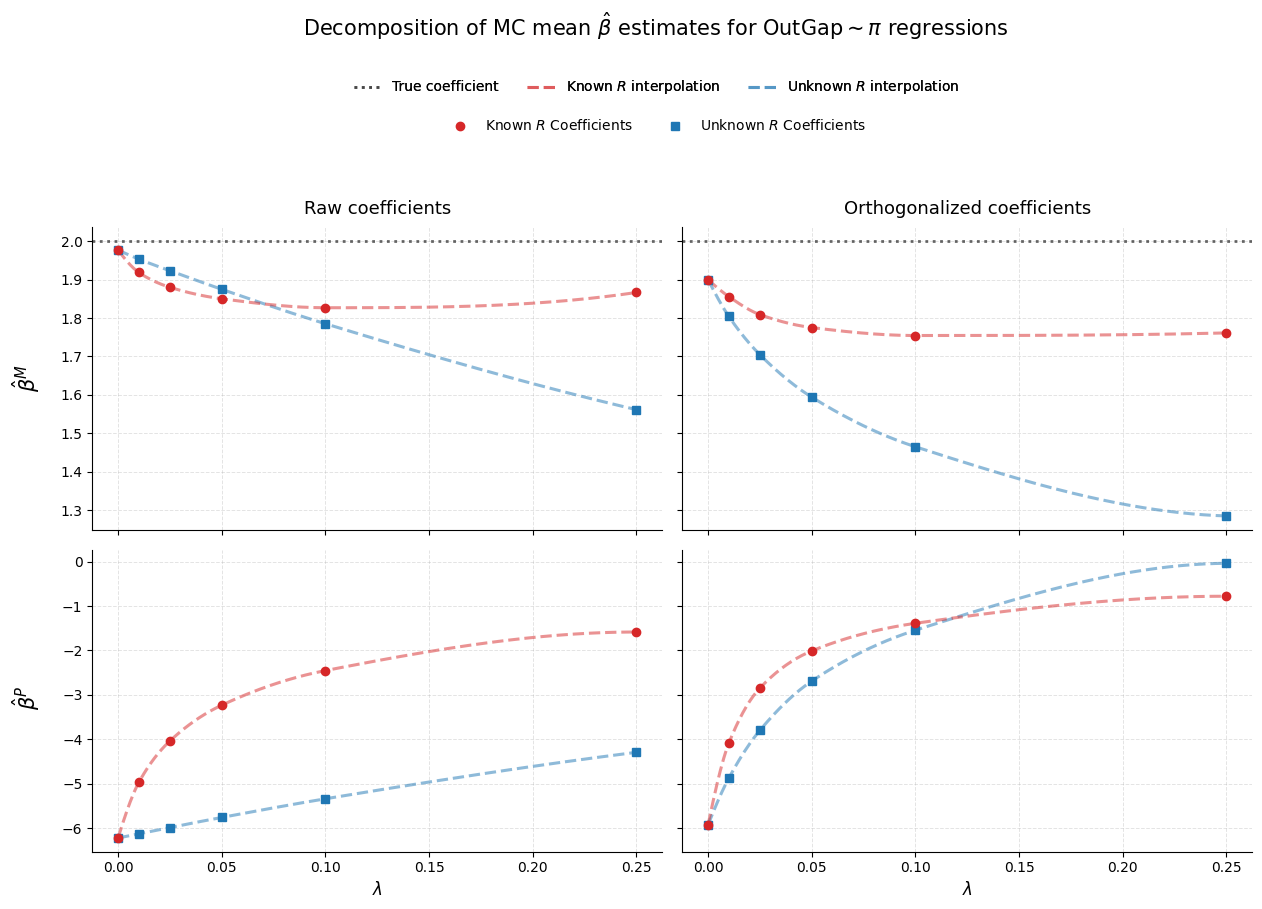

In [12]:
legend_order = [
    "True coefficient",
    r"Known $R$ interpolation",
    r"Unknown $R$ interpolation",
    r"Known $R$ Coefficients",
    r"Unknown $R$ Coefficients",
]

fig, ax = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey="row")

x = np.asarray(_LAMBDA_VALUES)
x_grid = np.linspace(x.min(), x.max(), 300)

err_style = dict(
    capsize=0,
    elinewidth=0,
    linewidth=0,
    markersize=6,
)

line_style = dict(
    linewidth=2.2,
    alpha=0.5,
)

panels = [
    (
        ax[0, 0],
        "Raw coefficients",
        _UNKNOWN_COEFS_RAW,
        _UNKNOWN_COEFS_RAW_SD,
        _KNOWN_COEFS_RAW,
        _KNOWN_COEFS_RAW_SD,
        _TRUE_COEF,
    ),
    (
        ax[0, 1],
        "Orthogonalized coefficients",
        _UNKNOWN_COEFS_ORTH,
        _UNKNOWN_COEFS_ORTH_SD,
        _KNOWN_COEFS_ORTH,
        _KNOWN_COEFS_ORTH_SD,
        _TRUE_COEF,
    ),
    (
        ax[1, 0],
        None,
        _UNKNOWN_P_COEFS_RAW,
        _UNKNOWN_P_COEFS_RAW_SD,
        _KNOWN_P_COEFS_RAW,
        _KNOWN_P_COEFS_RAW_SD,
        None,
    ),
    (
        ax[1, 1],
        None,
        _UNKNOWN_P_COEFS_ORTH,
        _UNKNOWN_P_COEFS_ORTH_SD,
        _KNOWN_P_COEFS_ORTH,
        _KNOWN_P_COEFS_ORTH_SD,
        None,
    ),
]

for a, title, unknown, unknown_sd, known, known_sd, true_coef in panels:
    unknown = np.asarray(unknown)
    known = np.asarray(known)

    if true_coef is not None:
        a.axhline(
            true_coef,
            color="0.25",
            linestyle=":",
            linewidth=2,
            alpha=0.8,
            label="True coefficient",
        )

    # Interpolated guide lines
    a.plot(
        x_grid,
        PchipInterpolator(x, unknown)(x_grid),
        linestyle="--",
        color="C0",
        label=r"Unknown $R$ interpolation",
        **line_style,
    )

    a.plot(
        x_grid,
        PchipInterpolator(x, known)(x_grid),
        linestyle="--",
        label=r"Known $R$ interpolation",
        color="C3",
        **line_style,
    )

    unknown_err = a.errorbar(
        x,
        unknown,
        yerr=unknown_sd,
        fmt="s",
        color="C0",
        label=r"Unknown $R$ Coefficients",
        **err_style,
    )

    known_err = a.errorbar(
        x,
        known,
        yerr=known_sd,
        fmt="o",
        color="C3",
        label=r"Known $R$ Coefficients",
        **err_style,
    )

    for err in [unknown_err, known_err]:
        _, caplines, barlinecols = err

        for cap in caplines:
            cap.set_alpha(0.75)

        for barlinecol in barlinecols:
            barlinecol.set_alpha(0.75)

    a.set_title(title, fontsize=13, pad=10)
    a.set_xlabel(r"$\lambda$", fontsize=12)
    a.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.35)
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)
    a.tick_params(axis="both", labelsize=10)

ax[0, 0].set_xlabel("")
ax[0, 1].set_xlabel("")
ax[1, 0].set_xlabel(r"$\lambda$", fontsize=12)
ax[1, 1].set_xlabel(r"$\lambda$", fontsize=12)

handles, labels = ax[0, 0].get_legend_handles_labels()

label_to_handle = dict(zip(labels, handles))
ordered_handles = [label_to_handle[label] for label in legend_order]
ordered_labels = legend_order

# Top row: 3 entries
leg1 = fig.legend(
    ordered_handles[:3],
    ordered_labels[:3],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.09),
    ncol=3,
    frameon=False,
    fontsize=10,
)

# Bottom row: 2 entries, centered
leg2 = fig.legend(
    ordered_handles[3:],
    ordered_labels[3:],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=2,
    frameon=False,
    fontsize=10,
)

fig.add_artist(leg1)

fig.text(
    0.015,
    0.70,
    r"$\hat{\beta}^M$",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=15,
)

fig.text(
    0.015,
    0.30,
    r"$\hat{\beta}^P$",
    va="center",
    ha="center",
    rotation="vertical",
    fontsize=15,
)

fig.suptitle(
    r"Decomposition of MC mean $\hat{\beta}$ estimates for $\mathrm{OutGap}\sim\pi$ regressions",
    fontsize=15,
    y=1.16,
)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 1])
plt.show()

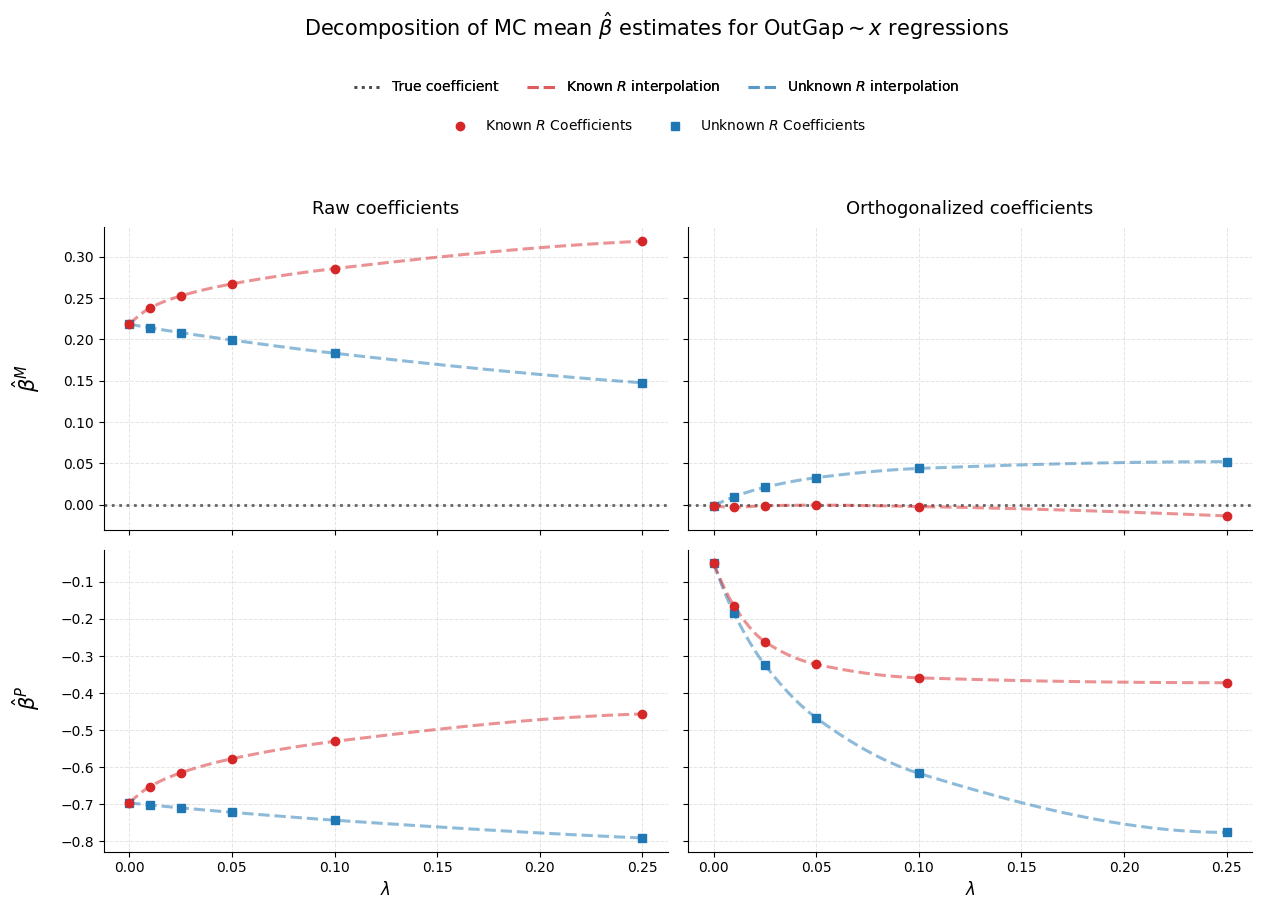

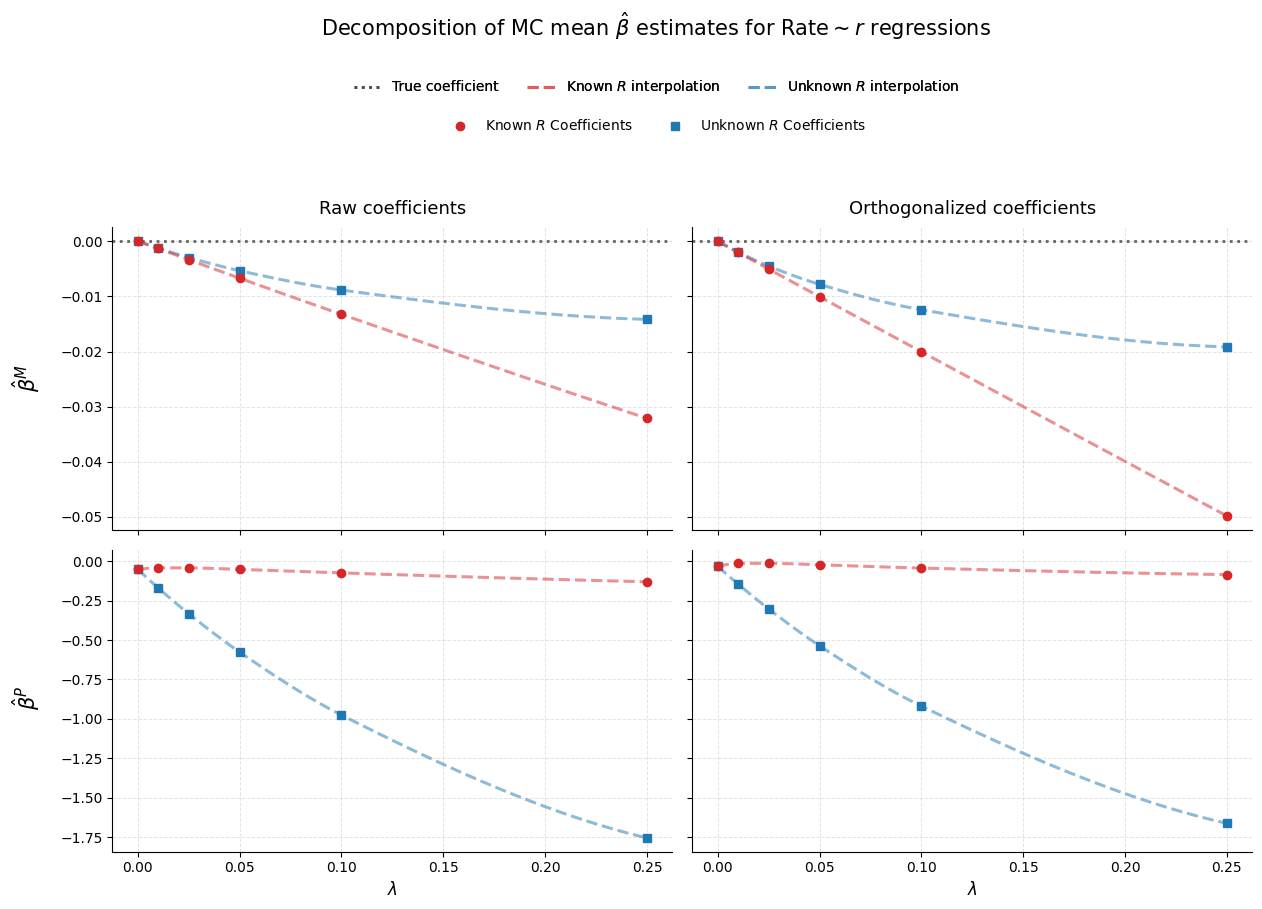

In [ ]:
# AI GENERATED CELL
# Reproduces the plot in the above cell for different regression specifications.
OUTGAP_X = {
    "title": r"$\mathrm{OutGap}\sim x$ regressions",
    "top_ylabel": r"$\hat{\beta}^{M}$",
    "bottom_ylabel": r"$\hat{\beta}^{P}$",
    "true_coef": 0.0,
    "measurement": {
        "raw": {
            "unknown": [0.2184862326084772, 0.21418540301194894, 0.20835319227667282, 0.19929806375135503, 0.183315885790707, 0.14750726918942703],
            "unknown_se": [0.00019973973862619533, 0.00020111535005083077, 0.00020290268073615083, 0.00020566748056547422, 0.0002104992521946926, 0.0002209501784286618],
            "known": [0.2184862326084772, 0.23800914703074225, 0.2527478579029434, 0.2673483078140993, 0.2858857032008861, 0.31904844152954814],
            "known_se": [0.00019973973862619533, 0.0002272611535857378, 0.0002567479322229133, 0.0002952269794334992, 0.00035771678990029323, 0.0005127581407898839],
        },
        "orth": {
            "unknown": [-0.0016634081983832897, 0.009489652732206786, 0.020945826083843825, 0.0325609988253186, 0.04376025154810374, 0.051983730376389585],
            "unknown_se": [0.00047656886137400285, 0.0004454097004970297, 0.0004103224481242756, 0.00037212134371634857, 0.0003297521480114157, 0.00028251502202534547],
            "known": [-0.0016634081983832897, -0.0032015261614320007, -0.001405339374149193, -0.0006751265517859319, -0.0023981347186861025, -0.01378879945923675],
            "known_se": [0.00047656886137400285, 0.00047783581189335953, 0.0004814979959289929, 0.00050663610743787, 0.0005725291573704667, 0.0007791441670894922],
        },
    },
    "prediction": {
        "raw": {
            "unknown": [-0.6963437504950213, -0.7020939583454308, -0.7098344687727642, -0.7218764033032874, -0.7431843072158903, -0.7911497843792118],
            "unknown_se": [0.00019674129217746013, 0.00019648604098094255, 0.00019458971359167374, 0.00019141260053728536, 0.000185112445663172, 0.00016776201439672652],
            "known": [-0.6963437504950213, -0.6525005185192144, -0.6154172227698537, -0.5772379604922163, -0.5305126484789399, -0.4564208337983743],
            "known_se": [0.00019674129217746013, 0.00022348050274394323, 0.0002493363442487602, 0.0002808057920790344, 0.00032767850564086433, 0.00042780100162644123],
        },
        "orth": {
            "unknown": [-0.04974565087171448, -0.1852765935236143, -0.32387920876784004, -0.46703742203667886, -0.6165631345483826, -0.7760903423749693],
            "unknown_se": [0.00032488580542808926, 0.00034880906304431066, 0.00035734201280393084, 0.00034482609593481137, 0.00030408441759926304, 0.00022381442095149325],
            "known": [-0.04974565087171448, -0.16477223801655386, -0.2613631065511411, -0.32240401065226876, -0.35892960600351437, -0.3721180966377033],
            "known_se": [0.00032488580542808926, 0.0003633166286312238, 0.0004071627498985488, 0.0004490599015616317, 0.0005075599899013872, 0.0006401502910934988],
        },
    },
}

RATE_R = {
    "title": r"$\mathrm{Rate}\sim r$ regressions",
    "top_ylabel": r"$\hat{\beta}^{M}$",
    "bottom_ylabel": r"$\hat{\beta}^{P}$",
    "true_coef": 0.0,
    "measurement": {
        "raw": {
            "unknown": [0.0, -0.0012428720920913652, -0.0029567079314441317, -0.005348573832228552, -0.008852060387707139, -0.01416398183090294],
            "unknown_se": [0.0, 0.0001572081262512959, 0.0002430535964984999, 0.0003317951889312346, 0.0004401014467427885, 0.0005965098226233057],
            "known": [0.0, -0.0013179631636565567, -0.0033565615895502334, -0.006711762417652202, -0.01325289969760535, -0.03211706586010076],
            "known_se": [0.0, 0.0001623931282265537, 0.00026134404407671157, 0.00037782779464856067, 0.0005521929892853533, 0.0009343371957119768],
        },
        "orth": {
            "unknown": [0.0, -0.0019674051953636183, -0.00449999375268292, -0.007819981025791825, -0.012421717560055329, -0.019151157783023336],
            "unknown_se": [0.0, 0.00016723840544364543, 0.00025790162828165223, 0.0003511748989101741, 0.00046481004189347265, 0.0006304629097064649],
            "known": [0.0, -0.0020295570676931813, -0.005049058524518852, -0.010059226038674896, -0.020041542867471826, -0.04981066270562285],
            "known_se": [0.0, 0.00017074976206436754, 0.0002733507579332735, 0.0003952311398823755, 0.0005807971071409672, 0.000999939048213925],
        },
    },
    "prediction": {
        "raw": {
            "unknown": [-0.05278915578172432, -0.17046125934202622, -0.333928376003418, -0.5767335289963543, -0.9754463402430733, -1.7540072729302556],
            "unknown_se": [0.0013023219391811339, 0.0013201058180920503, 0.0013373501597452712, 0.0013591724333807925, 0.0013785214771727438, 0.0013293037467258313],
            "known": [-0.05278915578172432, -0.042612419670731136, -0.04327906870397419, -0.052769744856937376, -0.07529849628449183, -0.13144982055732066],
            "known_se": [0.0013023219391811339, 0.001350927807006606, 0.0014039988632417461, 0.0014764453449750252, 0.0015925904822405585, 0.0018485520410432637],
        },
        "orth": {
            "unknown": [-0.03346809555334647, -0.14583658256970347, -0.3031108569498766, -0.5366308911681731, -0.9189387785320843, -1.661226480909113],
            "unknown_se": [0.0014186752480915773, 0.0014173459226603858, 0.0014138082329995907, 0.0014145110485828268, 0.0014145662729483164, 0.001358135649389272],
            "known": [-0.03346809555334647, -0.01401352782584747, -0.014123702235771866, -0.02419526128766945, -0.04437092668652964, -0.08587740452819966],
            "known_se": [0.0014186752480915773, 0.0014472032438723388, 0.0015000493550060378, 0.0015837451411360034, 0.0017256184015146576, 0.0020488037587867197],
        },
    },
}


def make_decomposition_plot(spec, outfile=None):
    legend_order = [
        "True coefficient",
        r"Known $R$ interpolation",
        r"Unknown $R$ interpolation",
        r"Known $R$ Coefficients",
        r"Unknown $R$ Coefficients",
    ]

    fig, ax = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey="row")

    x = np.asarray(_LAMBDA_VALUES, dtype=float)
    x_grid = np.linspace(x.min(), x.max(), 300)

    err_style = dict(capsize=0, elinewidth=0, linewidth=0, markersize=6)
    line_style = dict(linewidth=2.2, alpha=0.5)

    panels = [
        (ax[0, 0], "Raw coefficients", spec["measurement"]["raw"], spec.get("true_coef")),
        (ax[0, 1], "Orthogonalized coefficients", spec["measurement"]["orth"], spec.get("true_coef")),
        (ax[1, 0], None, spec["prediction"]["raw"], None),
        (ax[1, 1], None, spec["prediction"]["orth"], None),
    ]

    for a, title, values, true_coef in panels:
        unknown = np.asarray(values["unknown"], dtype=float)
        known = np.asarray(values["known"], dtype=float)
        unknown_sd = se_to_sd(np.asarray(values["unknown_se"], dtype=float))
        known_sd = se_to_sd(np.asarray(values["known_se"], dtype=float))

        if true_coef is not None:
            a.axhline(
                true_coef,
                color="0.25",
                linestyle=":",
                linewidth=2,
                alpha=0.8,
                label="True coefficient",
            )

        a.plot(
            x_grid,
            PchipInterpolator(x, unknown)(x_grid),
            linestyle="--",
            color="C0",
            label=r"Unknown $R$ interpolation",
            **line_style,
        )

        a.plot(
            x_grid,
            PchipInterpolator(x, known)(x_grid),
            linestyle="--",
            color="C3",
            label=r"Known $R$ interpolation",
            **line_style,
        )

        unknown_err = a.errorbar(
            x,
            unknown,
            yerr=unknown_sd,
            fmt="s",
            color="C0",
            label=r"Unknown $R$ Coefficients",
            **err_style,
        )

        known_err = a.errorbar(
            x,
            known,
            yerr=known_sd,
            fmt="o",
            color="C3",
            label=r"Known $R$ Coefficients",
            **err_style,
        )

        for err in [unknown_err, known_err]:
            _, caplines, barlinecols = err
            for cap in caplines:
                cap.set_alpha(0.75)
            for barlinecol in barlinecols:
                barlinecol.set_alpha(0.75)

        a.set_title(title, fontsize=13, pad=10)
        a.set_xlabel(r"$\lambda$", fontsize=12)
        a.grid(True, which="major", linestyle="--", linewidth=0.7, alpha=0.35)
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
        a.tick_params(axis="both", labelsize=10)

    ax[0, 0].set_xlabel("")
    ax[0, 1].set_xlabel("")
    ax[1, 0].set_xlabel(r"$\lambda$", fontsize=12)
    ax[1, 1].set_xlabel(r"$\lambda$", fontsize=12)

    handles, labels = ax[0, 0].get_legend_handles_labels()
    label_to_handle = dict(zip(labels, handles))

    ordered_labels = [label for label in legend_order if label in label_to_handle]
    ordered_handles = [label_to_handle[label] for label in ordered_labels]

    leg1 = fig.legend(
        ordered_handles[:3],
        ordered_labels[:3],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.09),
        ncol=3,
        frameon=False,
        fontsize=10,
    )

    leg2 = fig.legend(
        ordered_handles[3:],
        ordered_labels[3:],
        loc="upper center",
        bbox_to_anchor=(0.5, 1.04),
        ncol=2,
        frameon=False,
        fontsize=10,
    )

    fig.add_artist(leg1)

    fig.text(
        0.015,
        0.70,
        spec["top_ylabel"],
        va="center",
        ha="center",
        rotation="vertical",
        fontsize=15,
    )

    fig.text(
        0.015,
        0.30,
        spec["bottom_ylabel"],
        va="center",
        ha="center",
        rotation="vertical",
        fontsize=15,
    )

    fig.suptitle(
        rf"Decomposition of MC mean $\hat{{\beta}}$ estimates for {spec['title']}",
        fontsize=15,
        y=1.16,
    )

    plt.tight_layout(rect=[0.03, 0.03, 0.97, 1])

    if outfile is not None:
        fig.savefig(outfile, dpi=300, bbox_inches="tight")

    return fig, ax


fig1, ax1 = make_decomposition_plot(OUTGAP_X)
plt.show()

fig2, ax2 = make_decomposition_plot(RATE_R)
plt.show()
